---
# COSC2673 | COSC2793 (Computational) Machine Learning
## Week 2 Lab: **Reading Data & Exploratory Data Analysis (EDA)**
---

# Introduction

In this lab, we gain initial experience with some of the main Python tools used in this course, including NumPy, Matplotlib, and Pandas. We will load datasets, compute basic statistics, and visualise the results.

This lab assumes you are familiar with Python. Please complete the Week 01 lab: Introduction to Python before attempting this lab.

## Objectives
- Become more familiar with scientific Python.
- Load and inspect datasets.
- Compute basic statistics to understand datasets.
- Visualise data to support exploratory analysis.

## Dataset

We will examine two regression datasets. The first concerns house prices and factors related to them;
the second is daily bike-share rentals in Washington, D.C., USA, with features for time and weather.
The datasets are `housing.data.csv` and `bikeShareDay.csv` in the repository.

First, ensure both data files are available in your Jupyter workspace. Copy the data directories (`BostonHousingPrice` and `Bike-Sharing-Dataset`) into the current working folder.

Open the csv files in your favourite spreadsheets software (e.g. Excel) or editor (e.g. VS Code) and observe the data.

# Load Dataset

Next, we examine how to load these datasets into Python and Jupyter notebooks. We will first analyse the House prices dataset, then you’ll repeat the process to analyse the bike hire dataset.

First, we need to import a few packages that will be used for our data loading and analysis.

Pandas is a Python package for loading and handling data. 

We will use Matplotlib to visualise some of the distributions. 

Seaborn — a Python visualization library built on Matplotlib — provides a higher-level interface for attractive and informative statistical graphics. Learn more at: https://seaborn.pydata.org/

NumPy is a numeric library that has many useful mathematical and multidimensional arrays functionality.

In [21]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# plt.style.use('seaborn-v0_8')

Next, we use pandas to load the house price dataset:

In [22]:
bostonHouseFrame = pd.read_csv('./BostonHousingPrice/BostonHousingPrice/housing.data.csv', delimiter='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\prave\AppData\Local\Temp\ipykernel_16376\3316277548.py:1: SyntaxWarning: invalid escape sequence '\s'
  bostonHouseFrame = pd.read_csv('./BostonHousingPrice/BostonHousingPrice/housing.data.csv', delimiter='\s+')


Assuming the dataset is in `./BostonHousingPrice/housing.data.csv`.  Replace this with the relative or absolute path to your files.  

We strongly encourage you to look up the documentation of the functions we use in the lab, in this case, examine [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html).

The `read_csv()` command loads the input file, which is a csv formatted file delimited by tabs, into a **Pandas dataframe** (which can be thought of as a table). A dataframe can store the column names as well as the data.  Examine what has been loaded into the dataframe `bostonHouseFrame`.

In [23]:
print(bostonHouseFrame)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

If you are interested in checking only the first few rows of the dataframe to see if you have read the data in correctly, you can use the `head` method in dataframe.

In [24]:
bostonHouseFrame.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


Dataframes are a very useful data structure that will be used throughout the course, and we strongly suggest to familiarise yourselves with it.  Here is some introductory material for it: [Pandas Tutorial: DataFrames in Python](https://www.datacamp.com/community/tutorials/pandas-tutorial-dataframe-python).

Now, we have loaded the data into a dataframe and printed it out, next, we will compute some very basic statistics. The abbreviated column names:
- CRIM:      per capita crime rate by town
- ZN:        proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS:     proportion of non-retail business acres per town
- CHAS:      Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX:       nitric oxides concentration (parts per 10 million)
- RM:        average number of rooms per dwelling
- AGE:       proportion of owner-occupied units built prior to 1940
- DIS:       weighted distances to five Boston employment centres
- RAD:       index of accessibility to radial highways
- TAX:      full-value property-tax rate per USD10,000
- PTRATIO:  pupil-teacher ratio by town
- B:        1000 (Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT:    lower status of the population
- MEDV:     Median value of owner-occupied homes in USD1000's


The target column is **MEDV** and all the other columns are attributes.

Study the variables carefully and understand what they represent before moving to the next section. 

# Exploratory Data Analysis (EDA)

Often the first step in developing a machine learning solution for a given dataset is the EDA. EDA refers to the critical process of performing initial investigations on data so as to:

- Maximize insight into a dataset;
 - Uncover underlying structure;
 - Extract important variables;
 - Detect outliers and anomalies;
 - Test underlying assumptions;
 - Develop parsimonious models; and
 - Determine optimal factor settings.

with the help of summary statistics and graphical representations. The particular graphical techniques employed in EDA are often quite simple, consisting of various techniques of:

- Plotting the raw data, such as data traces, histograms, bi-histograms, probability plots, lag plots, block plots, and Youden plots.
- Plotting simple statistics, such as mean plots, standard deviation plots, box plots, and main effects plots of the raw data.
- Positioning such plots so as to maximize our natural pattern-recognition abilities, such as using multiple plots per page.

EDA is a subjective process and will depend on the task & the data you have. There is no globally correct way of doing this.

Usually you need to have a good understanding of the task before deciding what EDA techniques to use and continuously refine them based on the observations you make in the initial steps. 

Since we are still at the beginning of the course, let's explore some commonly used techniques. You will understand the significance of these methods and observations in terms of machine learning in the next fews weeks.

Let's first see the shape of the dataframe.

In [25]:
bostonHouseFrame.shape

(506, 14)

What does the above output tell you?

It is also a good practice to know the columns and their corresponding data types, along with finding whether they contain null values or not.

In [26]:
bostonHouseFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


Are there any missing values in the dataset? 

In Pandas, any missing values in the data (your input CSV file) is represented as NaN. 

Next, let's compute some summary statistics of the data we have read. The describe() function in Pandas is very handy in getting various summary statistics. This function returns the count, mean, standard deviation, minimum and maximum values and the quantiles of the data.

In [27]:
bostonHouseFrame.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


What insights did you get from the above output? 
Look closely at attributes `ZN`, and `CHAS`, do you see a difference in those two compared to the others? 

Data comes in two principle types in statistics, and it is crucial that we recognize the differences between these two types of data.

</br> 

1. Categorical Variables: These are data points that take on a finite number of values, AND whose values do not have a numerical interpretation.

    * Ordinal categorical variables take on values which can be logically ordered. For example, the reviews for a product which are given as 0-5 stars. 

    * Nominal categorical variables cannot be put in any logical order. Examples of this would be colours etc.

</br> 
 
2. Numerical Variables: These are variables which are numerical in nature.

    * Continuous variables take on a continuous values (no breaks). For example, height, and weight.

    * Discrete numerical variables take on a set of values which can be counted. For example, the number of rooms in a house.

</br> 

Identify what type of data is in the `bostonHouseFrame` dataframe.  

What is the type of data for CHAS and RAD?

## Data Distribution
One of the most important steps in EDA is estimating the distribution of a variable. Let's begin with a histogram plot.

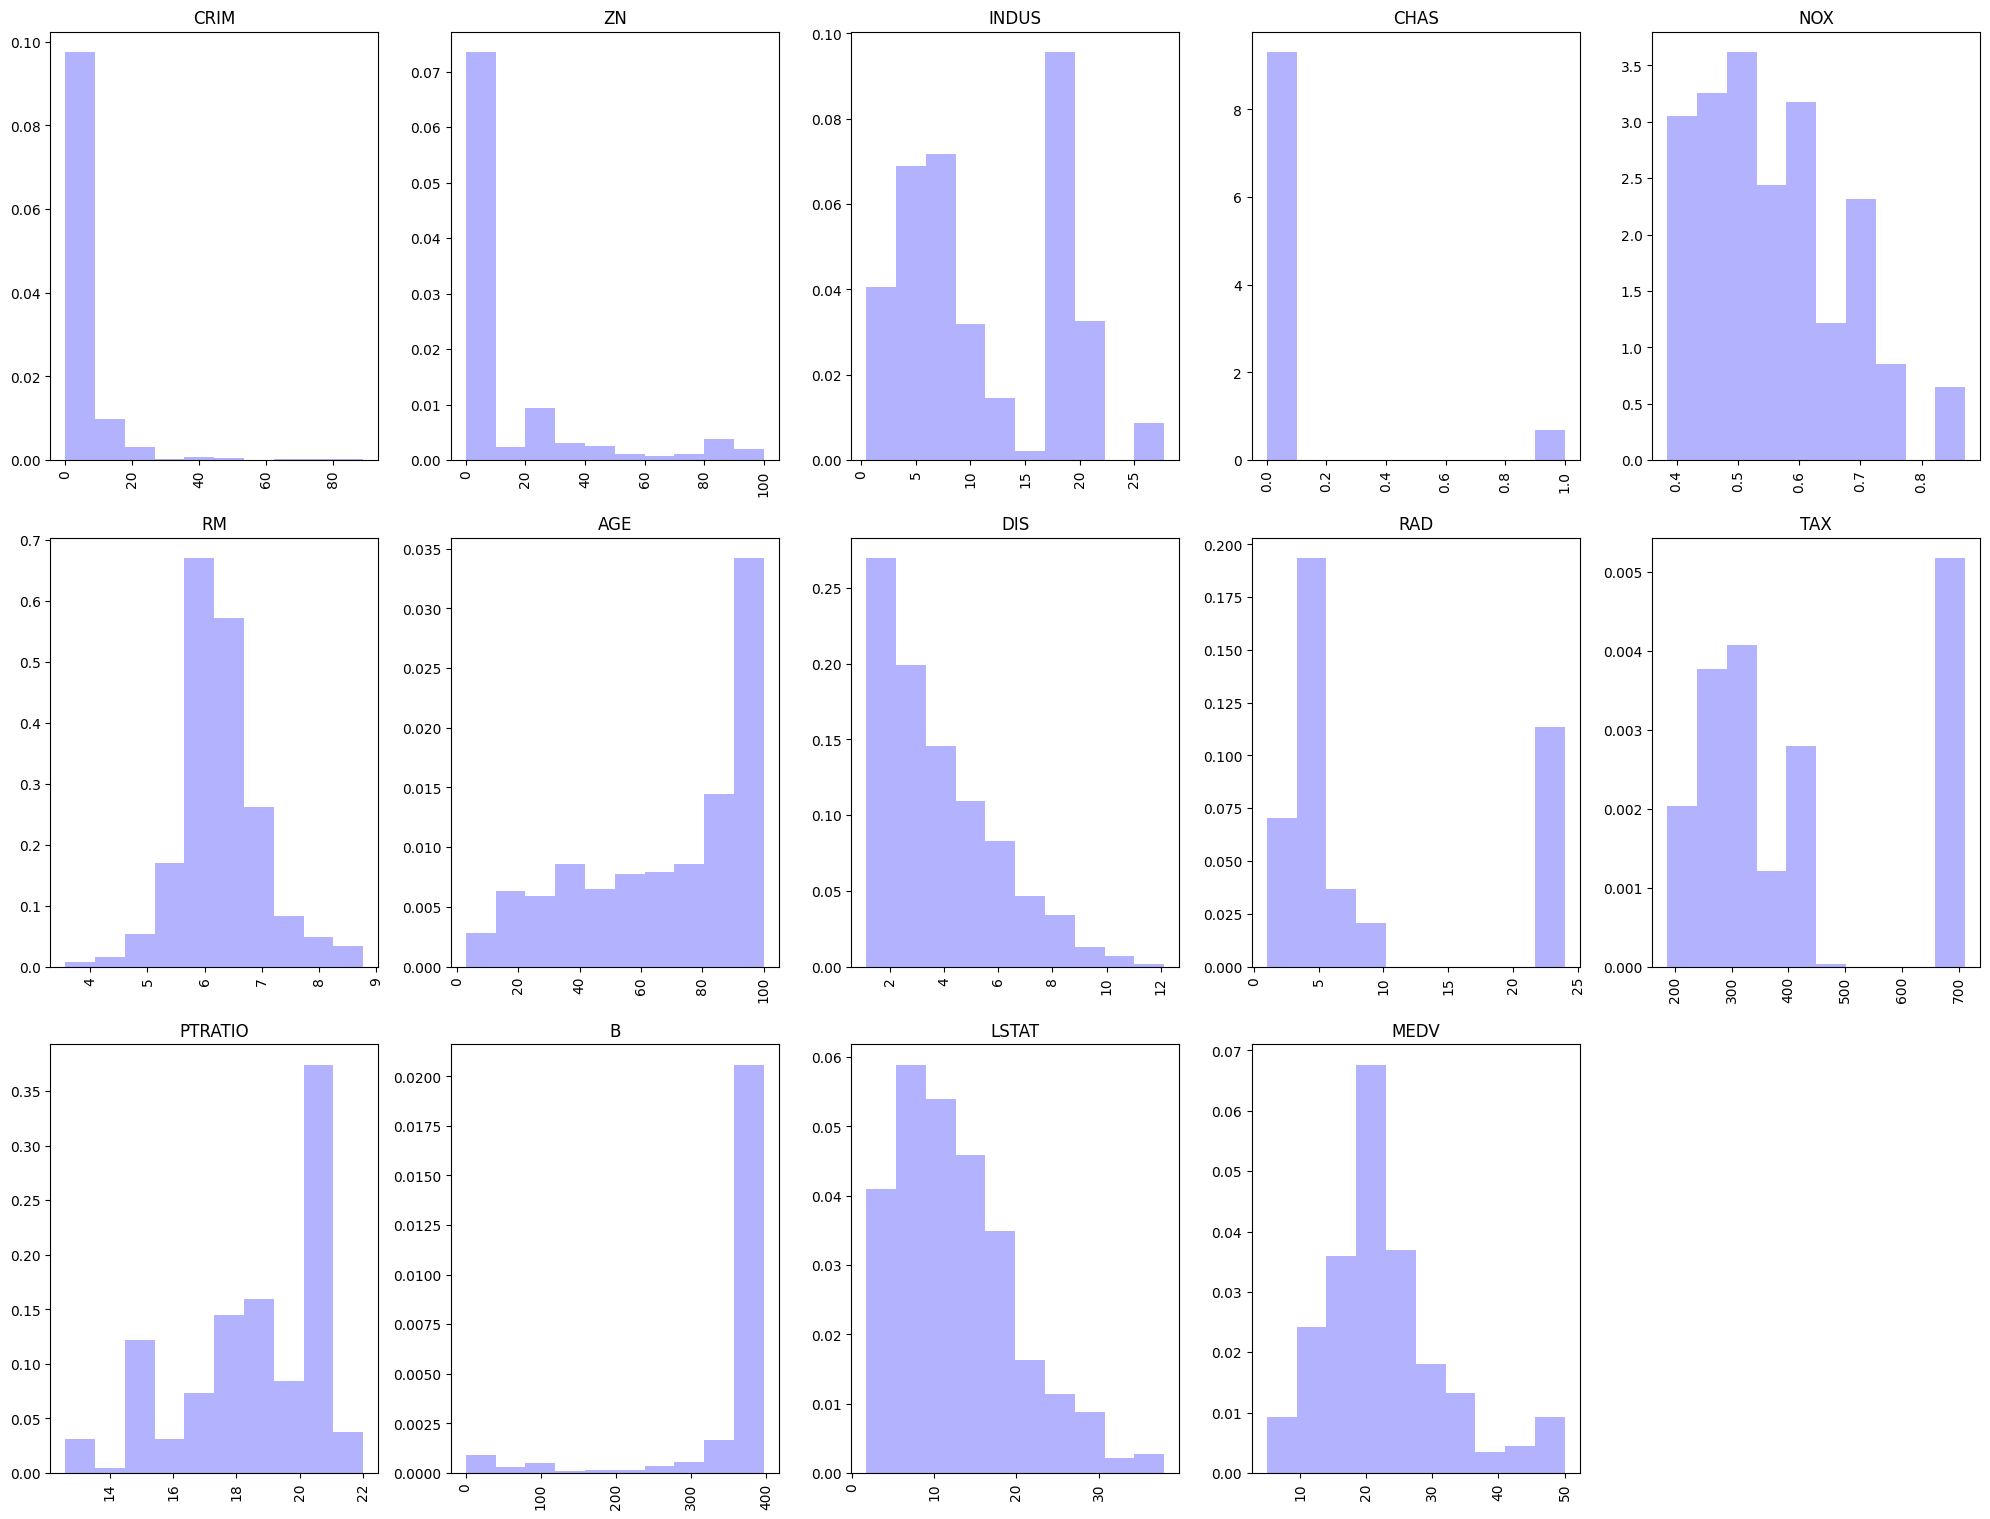

In [28]:
plt.figure(figsize=(20,20))
for i, col in enumerate(bostonHouseFrame.columns):
    plt.subplot(4,5,i+1)
    plt.hist(bostonHouseFrame[col], alpha=0.3, color='b', density=True)
    plt.title(col)
    plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

Always question the bin sizes of a histogram to see whether they are appropriate for the plot being presented. If you see a histogram with illogically large or small bin sizes and/or uneven bin sizes beware of the results being presented!

What observations did you make?

**Observations:** 
- Attribute CHAS is a categorical variable. Most data instances are from class 0 and only a few instances are from class 1.
- Many attributes are heavily skewed (e.g. CRIM, ZN, DIS, AGE, B).
- Attributes RAD and TAX have values that are far from the majority; further investigation is needed.
- Target variable MEDV is distributed around 22 with some extreme values around 50.
- ...

A box plot is another useful tool for examining data. Let's use a box plot to inspect the target variable `MEDV`.

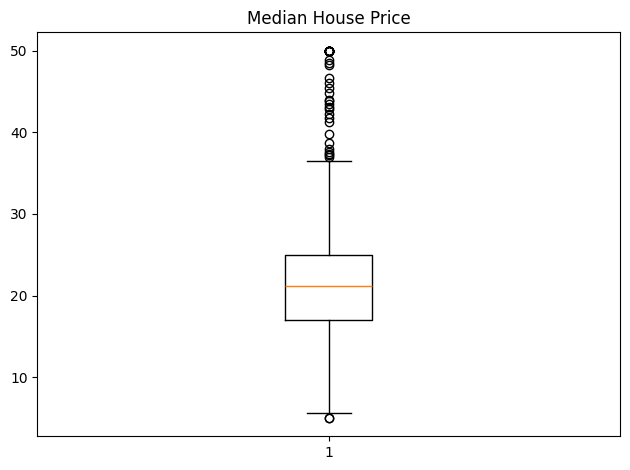

In [29]:
plt.boxplot(bostonHouseFrame['MEDV'])
plt.title('Median House Price')
plt.tight_layout()
plt.show()

**How to read Box Plots:**

- The thick line in the middle of the box gives the median value.
- The top of the box shows the 75th percentile (Q3).
- The bottom of the box shows the 25th percentile (Q1).
- The height of the box is the Interquartile Range (IQR = Q3 − Q1).
- The top whisker shows Q3 + 1.5 * IQR (upper cutoff for outliers by Tukey’s rule).
- The bottom whisker shows Q1 − 1.5 * IQR (lower cutoff for outliers by Tukey’s rule).
- Points outside the whiskers are often shown as individual markers and considered outliers.

An outlier is an observation that lies an unusually large distance from other values in a sample. Deciding whether
a point is 'abnormal' requires domain knowledge and analyst judgement; first characterize typical observations before flagging outliers.

## Relationship between Variables

In the previous section, we observed each attribute (data column) independently. Sometimes it is also useful to observe the relationship between two variables. There are several techniques that we can use for this purpose. One of the key techniques is a scatter plot. 

Since our task is to predict MEDV (target variable) using all other attributes, let's plot the relationship between MEDV and other columns.

We can use Matplotlib for these plots, but Seaborn — a Python visualization library built on Matplotlib —
provides a higher-level interface for attractive and informative statistical graphics. Learn more at: https://seaborn.pydata.org/

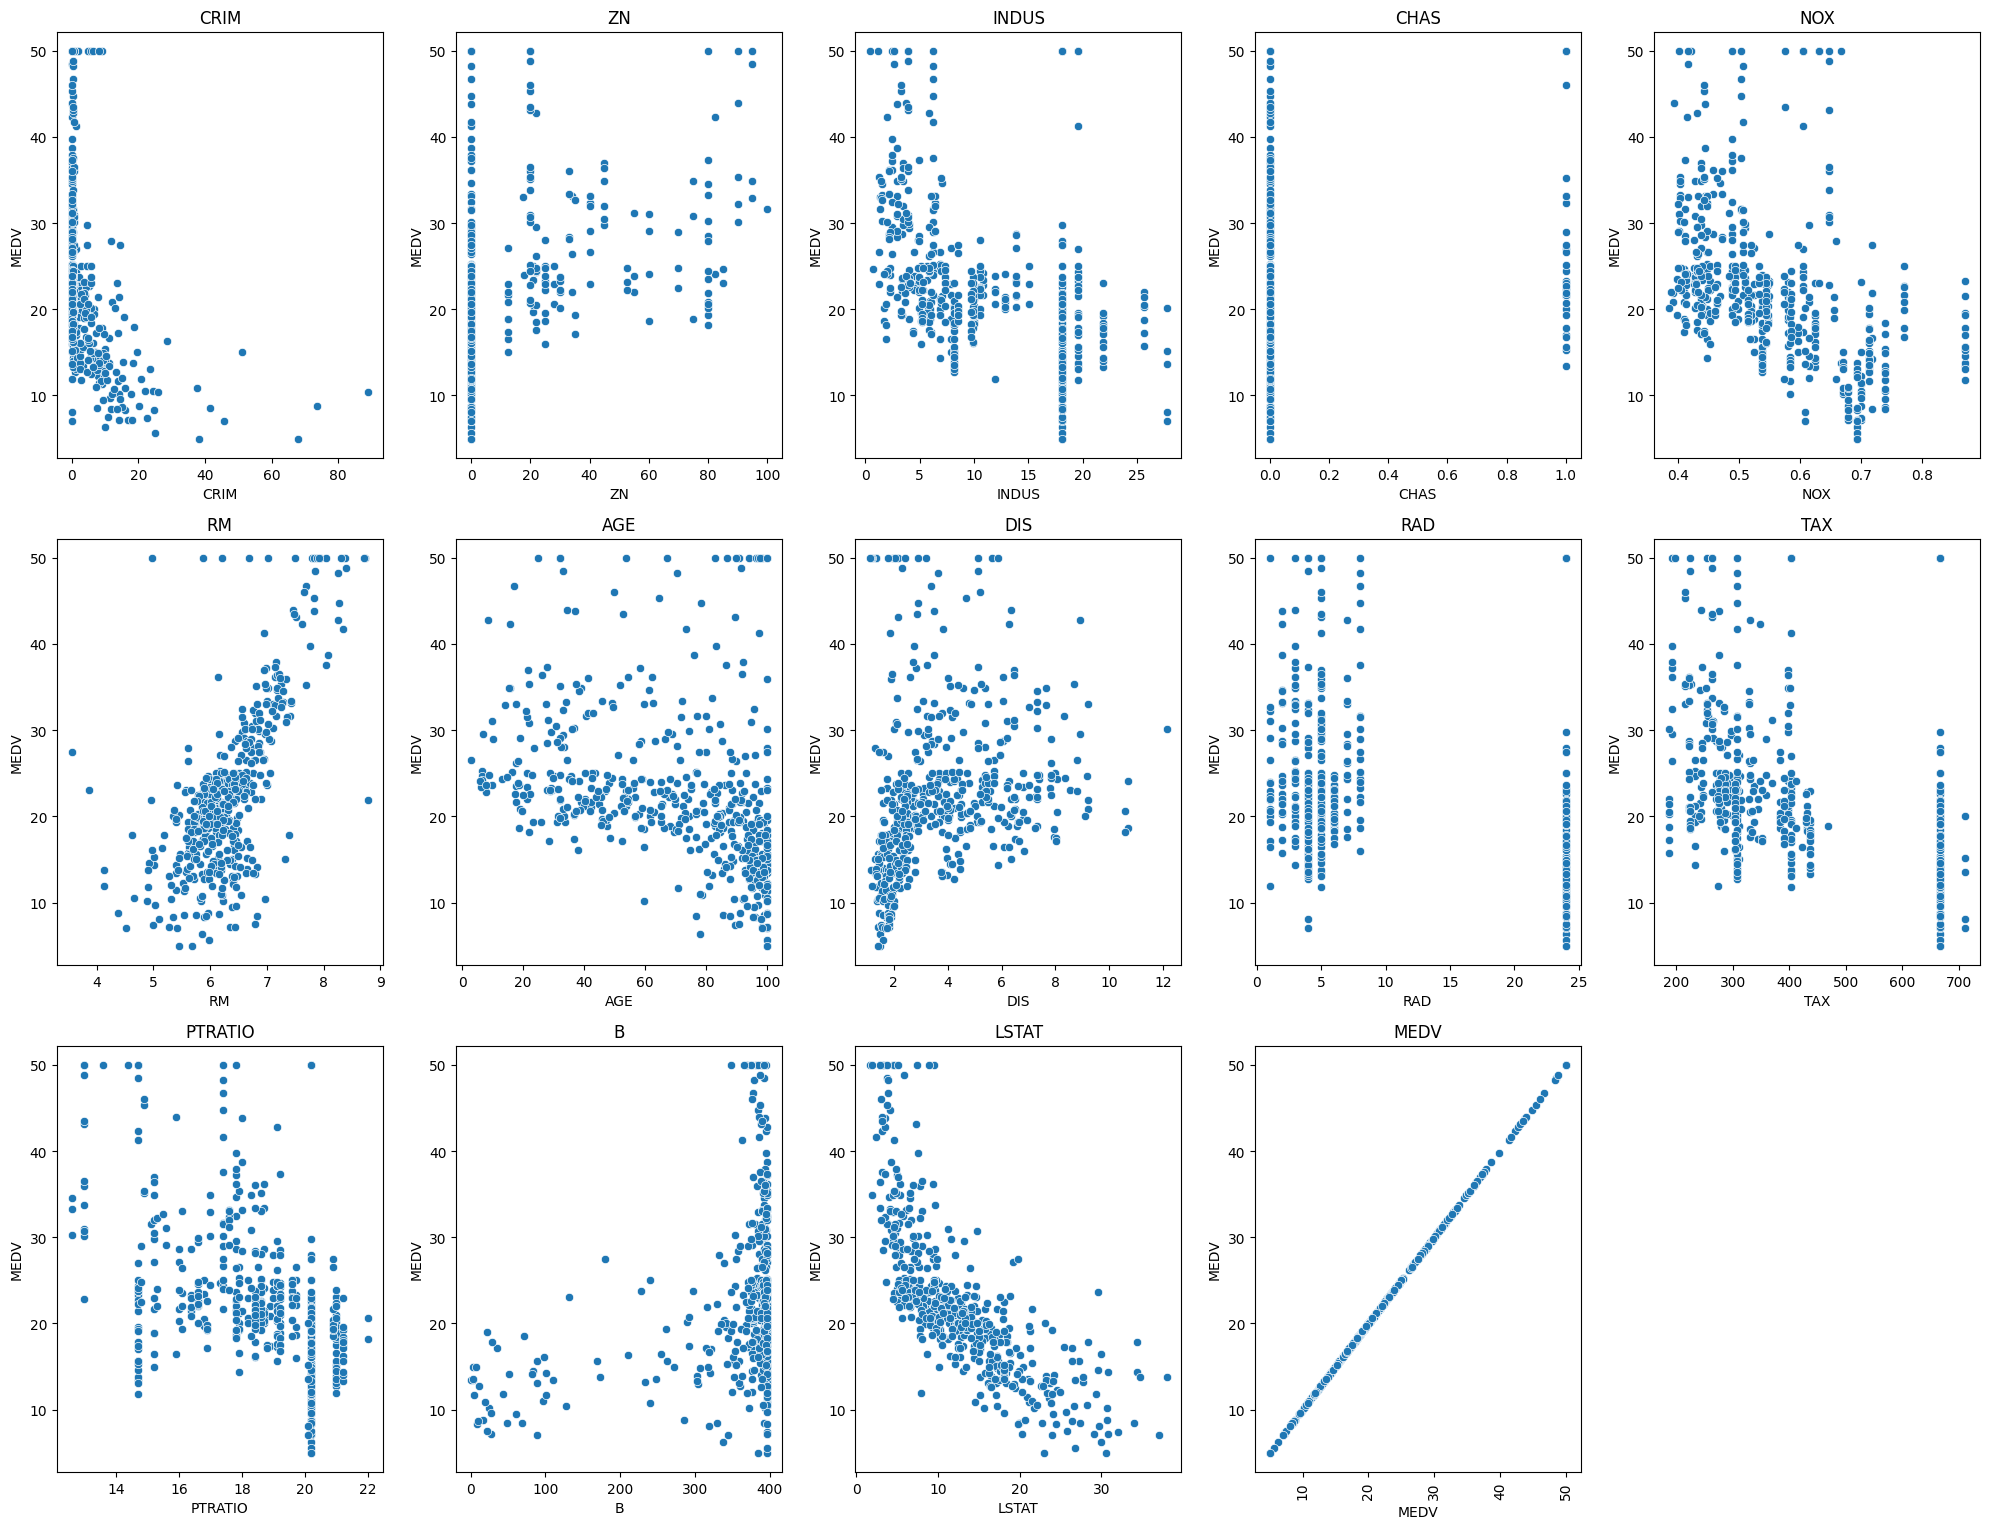

In [30]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(bostonHouseFrame.columns):
    plt.subplot(4, 5, i+1)
    sns.scatterplot(data=bostonHouseFrame, x=col, y='MEDV')
    # sns.regplot(x=col,y='MEDV', data=bostonHouseFrame)
    plt.title(col)
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

We have used the [seaborn scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) function above. Explore the function documentation to identify its features. 

Another tool that can be used is the [seaborn regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html), which also plots data and a linear regression model fit. Try this yourself. 

What observations did you make?

**Observations:** 
- There seems to be a good linear relationship between MEDV and RM.
- The relationship between MEDV and some variables appears to be nonlinear (e.g. LSTAT).
- ...

Scatter plots give good information when the attribute you are examining is numerical. What if there are categorical attributes?

If we have categorical attributes and continuous variables, we can examine them using a box plot. Let's look at the relationship between MEDV and CHAS.

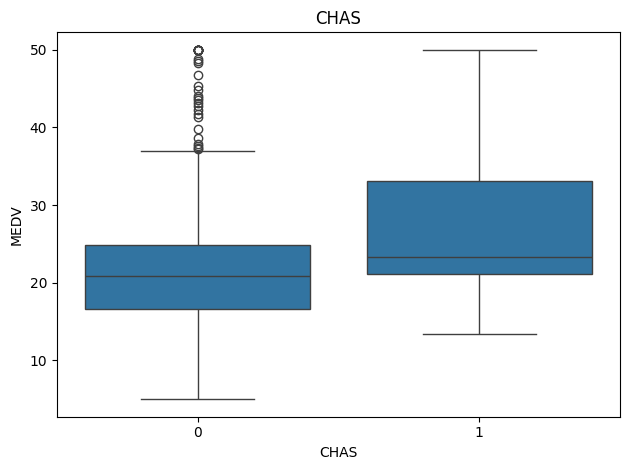

In [31]:
ax = sns.boxplot(y='MEDV', x='CHAS', data=bostonHouseFrame)
plt.title('CHAS')
plt.tight_layout()
plt.show()

What observations did you make?

**Observations:** 
- On average, the house price for data instances with CHAS=1 is higher than for data instances with CHAS=0

Correlation is another important statistic when developing ML models. Let's plot the correlation matrix for the numerical variables:

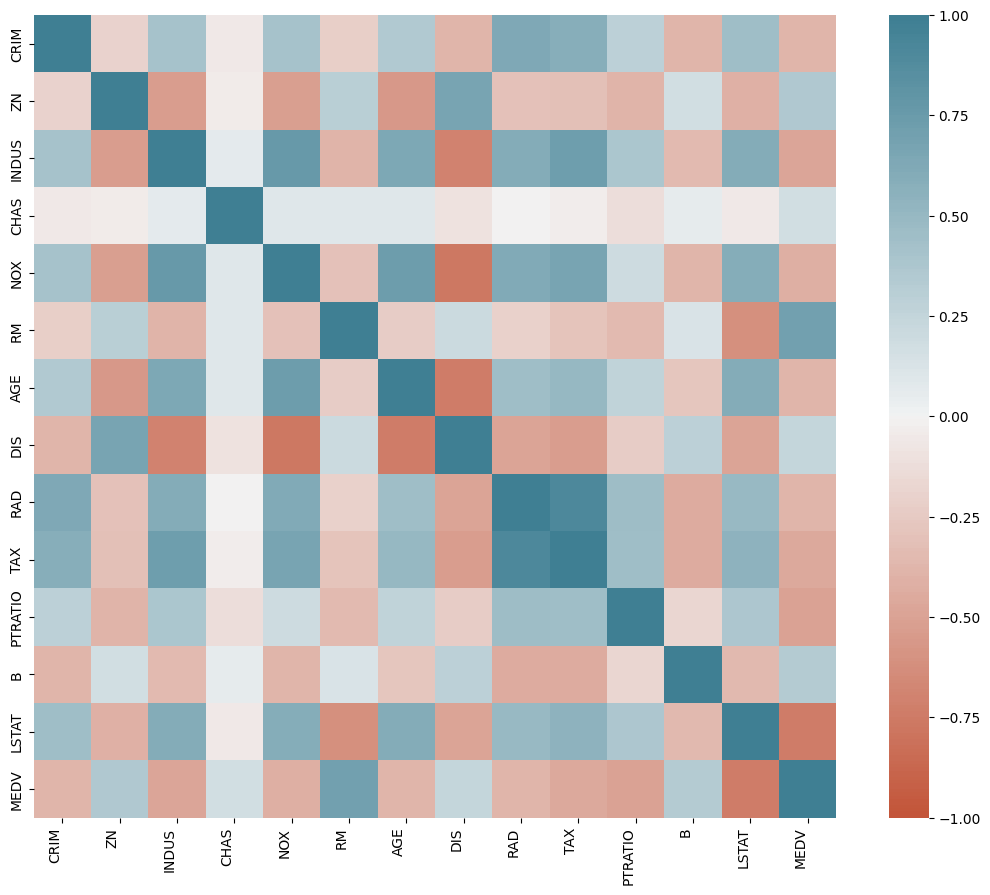

In [32]:
f, ax = plt.subplots(figsize=(11, 9))
corr = bostonHouseFrame.corr()
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
)
plt.tight_layout()
plt.show()

Correlation visualizes the relationship between each column in our dataset in a compact manner. A Simple description of correlation can be found [here](https://www.jmp.com/en_au/statistics-knowledge-portal/what-is-correlation.html#:~:text=Correlation%20is%20a%20statistical%20measure,statement%20about%20cause%20and%20effect.).

What observations did you make?

**Observations:** 
- Some attributes have high correlation between them. e.g. RAD and TAX, TAX and INDUS
- RM has a high positive correlation with the target variable and LSTAT has a high negative correlation
- ...

# Exercise: Analyse the Bike Share Data

Repeat the same process for the Daily Bike Share Rental dataset.

Answer the following questions and discuss this with your lab demonstrator. Please do attempt this, and don’t wait to see if solutions are released (they will not be!)
- What is the range of some of the attributes?
- Which of the features have a very different average to the others?
- Which feature is skewed (hint examine the histogram)?
- Which features are highly correlated?  

Relate above questions back to the domain of the dataset (bike sharing) and see if you can come up with
explanations for the observed data.

In [40]:
bikeShareDay = pd.read_csv('./Bike-Sharing-Dataset/Bike-Sharing-Dataset/bikeShareDay.csv')
bikeShareHour = pd.read_csv('./Bike-Sharing-Dataset/Bike-Sharing-Dataset/bikeShareHour.csv')

In [41]:
bikeShareDay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [42]:
bikeShareHour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [43]:
bikeShareHour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [44]:
bikeShareDay.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [45]:
bikeShareHour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [46]:
bikeShareDay.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
